# LANGKAH 0: INSTALASI DAN IMPORT LIBRARY

## Menginstal library yang diperlukan dari Hugging Face dan Scikit-learn.

In [1]:
!pip install transformers datasets scikit-learn scikit-multilearn emoji torch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 22.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import torch
import emoji
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import random
import numpy as np
import os
from torch import nn

In [3]:
def set_seed(seed_value=42):
    """Set seed for reproducibility."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    # Konfigurasi agar hasil deterministik (mungkin sedikit memperlambat training)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed_value)

# Set seed di awal
SEED = 42
set_seed(SEED)
print(f"Random seed set to {SEED}")

Random seed set to 42


# LANGKAH 1: MEMUAT DATASET

In [4]:
try:
    df = pd.read_csv('https://raw.githubusercontent.com/gikirima/TEA-emoji/refs/heads/v2.0/Dataset/dataset_NoEmoji_clean.csv')
    print("Dataset berhasil dimuat.")

except FileNotFoundError:
    print("Error: File tidak ditemukan.")
    print("Silakan unggah file tersebut terlebih dahulu.")
    # Hentikan eksekusi jika file tidak ada
    exit()

Dataset berhasil dimuat.


# LANGKAH 3: MEMUAT TOKENIZER DAN MODEL (Integrasi dari Untitled11.ipynb)

## Kita memuat model dan tokenizer dasar, lalu langsung menambahkan token emoji dan menyesuaikan ukuran embedding model.

In [5]:
model_name = "indobenchmark/indobert-base-p1"

# Tentukan kolom label Anda. Sesuaikan jika nama kolom di CSV Anda berbeda.
label_columns = ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']

num_labels = len(label_columns)

print(f"\nMemuat tokenizer '{model_name}'...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

print(f"Memuat model '{model_name}' untuk klasifikasi multi-label dengan {num_labels} label...")
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    problem_type="multi_label_classification" # Penting untuk klasifikasi multi-label
)

print("Tokenizer dan model baseline siap digunakan.")


Memuat tokenizer 'indobenchmark/indobert-base-p1'...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Memuat model 'indobenchmark/indobert-base-p1' untuk klasifikasi multi-label dengan 8 label...


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Tokenizer dan model baseline siap digunakan.


# LANGKAH 4: PERSIAPAN DATASET UNTUK HUGGING FACE

## Mengubah format dari Pandas DataFrame menjadi Hugging Face Dataset.


Memulai pembagian dataset dengan metode iterative_train_test_split...


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]


Mengubah format DataFrame menjadi Hugging Face Dataset...

Melakukan tokenisasi dan pemformatan label pada semua set data...


Map:   0%|          | 0/73161 [00:00<?, ? examples/s]

Map:   0%|          | 0/73161 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/18353 [00:00<?, ? examples/s]

Map:   0%|          | 0/22378 [00:00<?, ? examples/s]

Map:   0%|          | 0/22378 [00:00<?, ? examples/s]


--- Pembagian Data Selesai (Hasil Seharusnya Benar) ---
Jumlah data latih (train): 73161 (Target: ~64%)
Jumlah data validasi (validation): 18353 (Target: ~16%)
Jumlah data uji (test): 22378 (Target: ~20%)
Total: 113892

Menghitung dan menampilkan distribusi label di setiap set data...


/tmp/ipython-input-3587689303.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist_df.index, y='Train', data=dist_df, ax=axes[0], palette='viridis')
/tmp/ipython-input-3587689303.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist_df.index, y='Validation', data=dist_df, ax=axes[1], palette='viridis')
/tmp/ipython-input-3587689303.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist_df.index, y='Test', data=dist_df, ax=axes[2], palette='viridis')


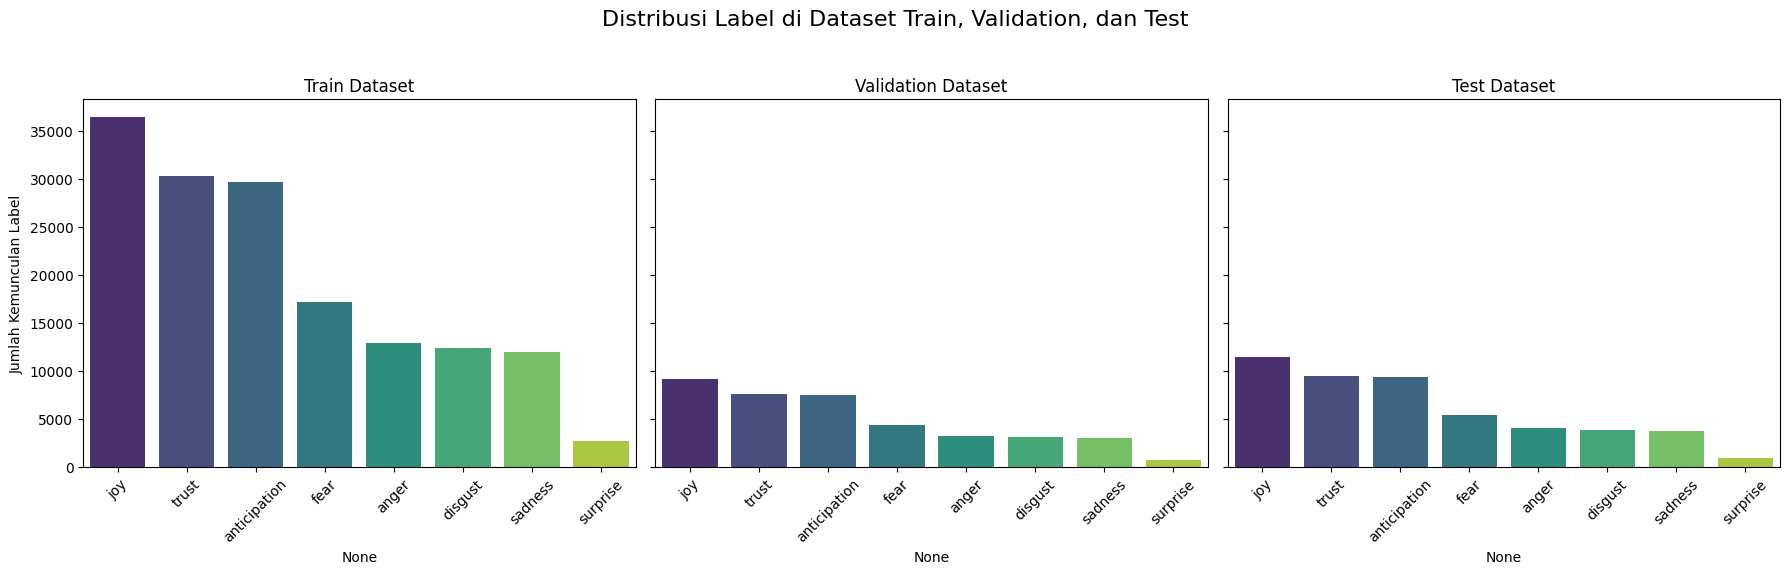


Distribusi label berhasil ditampilkan.


In [6]:
# Pastikan Anda sudah menginstal scikit-multilearn
# !pip install scikit-multilearn --quiet
from skmultilearn.model_selection import iterative_train_test_split
import numpy as np
import pandas as pd

print("\nMemulai pembagian dataset dengan metode iterative_train_test_split...")

# Definisikan kolom fitur (X) dan label (y)
label_columns = ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']

# Penting: Konversi kolom teks dan label ke format numpy untuk splitter
X = df['text'].to_numpy().reshape(-1, 1)
y = df[label_columns].to_numpy()


# --- Pembagian Data yang Benar ---

# 1. Pisahkan 20% data untuk set tes (unseen data)
# Fungsi ini mengembalikan X dan y untuk masing-masing set
X_train_val, y_train_val, X_test, y_test = iterative_train_test_split(X, y, test_size=0.2)

# 2. Pisahkan sisa 80% (train_val) menjadi data latih (train) dan validasi (validation)
# Proporsi untuk validasi dari sisa data adalah 0.16 / 0.80 = 0.2
X_train, y_train, X_val, y_val = iterative_train_test_split(X_train_val, y_train_val, test_size=0.2)

# --- Rekonstruksi DataFrame dari hasil split ---
# Kita perlu mengubah kembali hasil split (numpy array) menjadi Pandas DataFrame
# untuk digunakan oleh library 'datasets'

# Membuat DataFrame train
df_train = pd.DataFrame(X_train.flatten(), columns=['text'])
for i, col in enumerate(label_columns):
    df_train[col] = y_train[:, i]

# Membuat DataFrame validasi
df_val = pd.DataFrame(X_val.flatten(), columns=['text'])
for i, col in enumerate(label_columns):
    df_val[col] = y_val[:, i]

# Membuat DataFrame test
df_test = pd.DataFrame(X_test.flatten(), columns=['text'])
for i, col in enumerate(label_columns):
    df_test[col] = y_test[:, i]

# --- Konversi ke Hugging Face Dataset ---
print("\nMengubah format DataFrame menjadi Hugging Face Dataset...")
train_dataset_hf = Dataset.from_pandas(df_train)
eval_dataset_hf = Dataset.from_pandas(df_val)
test_dataset_hf = Dataset.from_pandas(df_test)

# --- Tokenisasi dan Pemrosesan (diterapkan ke setiap dataset) ---
# Fungsi untuk tokenisasi teks
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Fungsi untuk memformat kolom label
def format_labels(example):
    example["labels"] = [float(example[label]) for label in label_columns]
    return example

print("\nMelakukan tokenisasi dan pemformatan label pada semua set data...")
train_dataset = train_dataset_hf.map(tokenize_function, batched=True).map(format_labels)
eval_dataset = eval_dataset_hf.map(tokenize_function, batched=True).map(format_labels)
test_dataset = test_dataset_hf.map(tokenize_function, batched=True).map(format_labels)


print("\n--- Pembagian Data Selesai (Hasil Seharusnya Benar) ---")
print(f"Jumlah data latih (train): {len(train_dataset)} (Target: ~64%)")
print(f"Jumlah data validasi (validation): {len(eval_dataset)} (Target: ~16%)")
print(f"Jumlah data uji (test): {len(test_dataset)} (Target: ~20%)")
print(f"Total: {len(train_dataset) + len(eval_dataset) + len(test_dataset)}")

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\nMenghitung dan menampilkan distribusi label di setiap set data...")

def get_label_distribution(dataset_hf, label_columns):
    """Menghitung jumlah kemunculan setiap label dalam dataset Hugging Face."""
    df = dataset_hf.to_pandas()
    distribution = df[label_columns].sum().sort_values(ascending=False)
    return distribution

# Hitung distribusi untuk setiap set
train_label_dist = get_label_distribution(train_dataset_hf, label_columns)
eval_label_dist = get_label_distribution(eval_dataset_hf, label_columns)
test_label_dist = get_label_distribution(test_dataset_hf, label_columns)

# Buat DataFrame gabungan untuk plotting
dist_df = pd.DataFrame({
    'Train': train_label_dist,
    'Validation': eval_label_dist,
    'Test': test_label_dist
})

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Distribusi Label di Dataset Train, Validation, dan Test', fontsize=16)

# Plot Train
sns.barplot(x=dist_df.index, y='Train', data=dist_df, ax=axes[0], palette='viridis')
axes[0].set_title('Train Dataset')
axes[0].set_ylabel('Jumlah Kemunculan Label')
axes[0].tick_params(axis='x', rotation=45)

# Plot Validation
sns.barplot(x=dist_df.index, y='Validation', data=dist_df, ax=axes[1], palette='viridis')
axes[1].set_title('Validation Dataset')
axes[1].set_ylabel('') # Hide y-label as it's shared
axes[1].tick_params(axis='x', rotation=45)

# Plot Test
sns.barplot(x=dist_df.index, y='Test', data=dist_df, ax=axes[2], palette='viridis')
axes[2].set_title('Test Dataset')
axes[2].set_ylabel('') # Hide y-label as it's shared
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

print("\nDistribusi label berhasil ditampilkan.")

In [7]:
# --- HITUNG CLASS WEIGHTS (Penanganan Imbalance) ---
# Menggunakan strategi pos_weight untuk BCEWithLogitsLoss
# Formula: (Jumlah Negatif) / (Jumlah Positif) untuk setiap label

labels_array = df_train[label_columns].to_numpy()
# Menghitung jumlah positif per kelas
num_positives = labels_array.sum(axis=0)
# Menghitung jumlah negatif per kelas
num_negatives = labels_array.shape[0] - num_positives

# Menghitung pos_weight
# Tambahkan epsilon kecil untuk menghindari pembagian dengan nol jika ada kelas kosong
pos_weights_tensor = torch.tensor((num_negatives / (num_positives + 1e-5)), dtype=torch.float)

# Pindahkan ke GPU jika tersedia
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weights_tensor = pos_weights_tensor.to(device)

print("\nClass Weights (pos_weight) per label:")
for label, weight in zip(label_columns, pos_weights_tensor):
    print(f"{label}: {weight.item():.4f}")


Class Weights (pos_weight) per label:
joy: 1.0070
trust: 1.4132
fear: 3.2555
surprise: 25.9569
sadness: 5.1069
disgust: 4.9408
anger: 4.6952
anticipation: 1.4625


# LANGKAH 5: MENDEFINISIKAN METRIK EVALUASI
## Fungsi ini akan menghitung metrik performa model saat evaluasi.

In [8]:
def compute_metrics(p):
    logits, labels = p
    # Menggunakan sigmoid karena ini adalah klasifikasi multi-label
    preds_proba = torch.sigmoid(torch.tensor(logits))
    # Threshold 0.5 untuk menentukan apakah label aktif (1) atau tidak (0)
    preds = (preds_proba > 0.5).int().numpy()
    labels = labels.astype(int)

    f1_micro = f1_score(labels, preds, average='micro')
    f1_macro = f1_score(labels, preds, average='macro')
    precision_micro = precision_score(labels, preds, average='micro')
    recall_micro = recall_score(labels, preds, average='micro')

    return {
        'f1_macro': f1_macro,
        'f1_micro': f1_micro,
        'precision_micro': precision_micro,
        'recall_micro': recall_micro,
        'accuracy': accuracy_score(labels, preds), # Accuracy berbasis exact match
    }

# LANGKAH 6: KONFIGURASI DAN PROSES TRAINING

## Menentukan argumen pelatihan dan memulai proses fine-tuning.

In [9]:
# Membuat Custom Trainer untuk Class Weights
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Menggunakan BCEWithLogitsLoss dengan pos_weight yang sudah dihitung
        # pos_weights_tensor harus bisa diakses (global variable dari langkah sebelumnya)
        loss_fct = nn.BCEWithLogitsLoss(pos_weight=pos_weights_tensor)

        # Labels harus float untuk BCEWithLogitsLoss
        loss = loss_fct(logits, labels.float())

        return (loss, outputs) if return_outputs else loss



In [10]:
# WANDB integration for experiment tracking.
try:
    from google.colab import userdata
    wandb_api_key = userdata.get('WANDB_API_KEY')
    import wandb
    if wandb_api_key:
        wandb.login(key=wandb_api_key)
        print("WANDB login successful.")
        wandb.init(
            project="test_model_Training",
            name="baseline_noemoji_model_run_5",
        )
        report_to = "wandb"
    else:
        print("WANDB_API key not found. Skipping WANDB logging.")
        report_to = "none"
except (ImportError, KeyError):
    print("Not in Colab or WANDB key not set. Skipping WANDB logging.")
    report_to = "none"


training_args = TrainingArguments(
    # --- Direktori & Strategi ---
    output_dir="./results",
    eval_strategy="steps",          # Evaluasi per step
    save_strategy="steps",          # Simpan checkpoint per step
    load_best_model_at_end=True,   # Muat model terbaik di akhir
    metric_for_best_model="f1_macro",
    greater_is_better=True,         # f1_macro yang lebih tinggi lebih baik

    # --- Frekuensi Step ---
    logging_steps=250,             # Catat log setiap 250 steps
    eval_steps=1500,               # Evaluasi setiap 1500 steps
    save_steps=1500,               # Simpan checkpoint setiap 1500 steps
    save_total_limit=3,            # Simpan maksimal 3 checkpoint (termasuk yg terbaik)

    # --- Hyperparameter Training ---
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    learning_rate=2e-5,            # Learning rate yang umum untuk fine-tuning BERT
    warmup_steps=500,              # Pemanasan untuk menstabilkan training
    weight_decay=0.01,             # Regularisasi untuk mencegah overfitting

    # --- Optimasi Performa ---
    fp16=True,                     # Aktifkan mixed precision (mempercepat training di GPU T4/V100)
    report_to="wandb",              # Jika Anda menggunakan W&B untuk logging
    seed=SEED,                     # Random Seed di sini
    data_seed=SEED                 # Data Seed di sini
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics # Masih pakai metrics standar (threshold 0.5) untuk monitoring
)



print("\nMemulai proses fine-tuning model dengan class weight...")
trainer.train()

print("\nPelatihan selesai.")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: fikrihanif130 (3fa) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


WANDB login successful.


/tmp/ipython-input-3202340418.py:52: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(



Memulai proses fine-tuning model dengan class weight...


Step,Training Loss,Validation Loss,F1 Macro,F1 Micro,Precision Micro,Recall Micro,Accuracy
1500,0.542500,0.520997,0.678027,0.730164,0.655709,0.823693,0.318422


Step,Training Loss,Validation Loss,F1 Macro,F1 Micro,Precision Micro,Recall Micro,Accuracy
1500,0.542500,0.520997,0.678027,0.730164,0.655709,0.823693,0.318422
3000,0.433500,0.490028,0.695733,0.748408,0.679624,0.832682,0.348608
4500,0.421200,0.495935,0.716973,0.763004,0.702658,0.834688,0.370566
6000,0.324000,0.550325,0.731211,0.776481,0.724684,0.836251,0.396012
7500,0.268700,0.584193,0.736974,0.779351,0.735819,0.828357,0.406963
9000,0.250500,0.587209,0.739621,0.781303,0.739682,0.827888,0.406473



Pelatihan selesai.


# LANGKAH 7: EVALUASI AKHIR
## Mengevaluasi model terbaik pada data uji.


=== 1. PENCARIAN DYNAMIC THRESHOLD (MENGGUNAKAN VALIDATION SET) ===


Mengoptimalkan threshold per label...
          Label  Optimized Threshold
0           joy                 0.50
1         trust                 0.45
2          fear                 0.60
3      surprise                 0.90
4       sadness                 0.65
5       disgust                 0.75
6         anger                 0.65
7  anticipation                 0.35

=== 2. EVALUASI TEST SET (DENGAN DYNAMIC THRESHOLD) ===



[Global Metrics]
Accuracy (Exact Match): 0.4046
F1 Macro Average      : 0.7472
F1 Micro Average      : 0.7885

[Detailed Metrics Per Class]
       Label  Threshold  Precision  Recall  F1-Score
         joy       0.50     0.8975  0.8949    0.8962
       trust       0.45     0.8096  0.8828    0.8446
        fear       0.60     0.7775  0.8364    0.8059
    surprise       0.90     0.6171  0.4457    0.5176
     sadness       0.65     0.7089  0.7278    0.7182
     disgust       0.75     0.7159  0.7911    0.7516
       anger       0.65     0.7294  0.7950    0.7608
anticipation       0.35     0.5967  0.7986    0.6830

--- SKLEARN CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

         joy       0.90      0.89      0.90     11392
       trust       0.81      0.88      0.84      9474
        fear       0.78      0.84      0.81      5373
    surprise       0.62      0.45      0.52       857
     sadness       0.71      0.73      0.72      3744
     disgust      

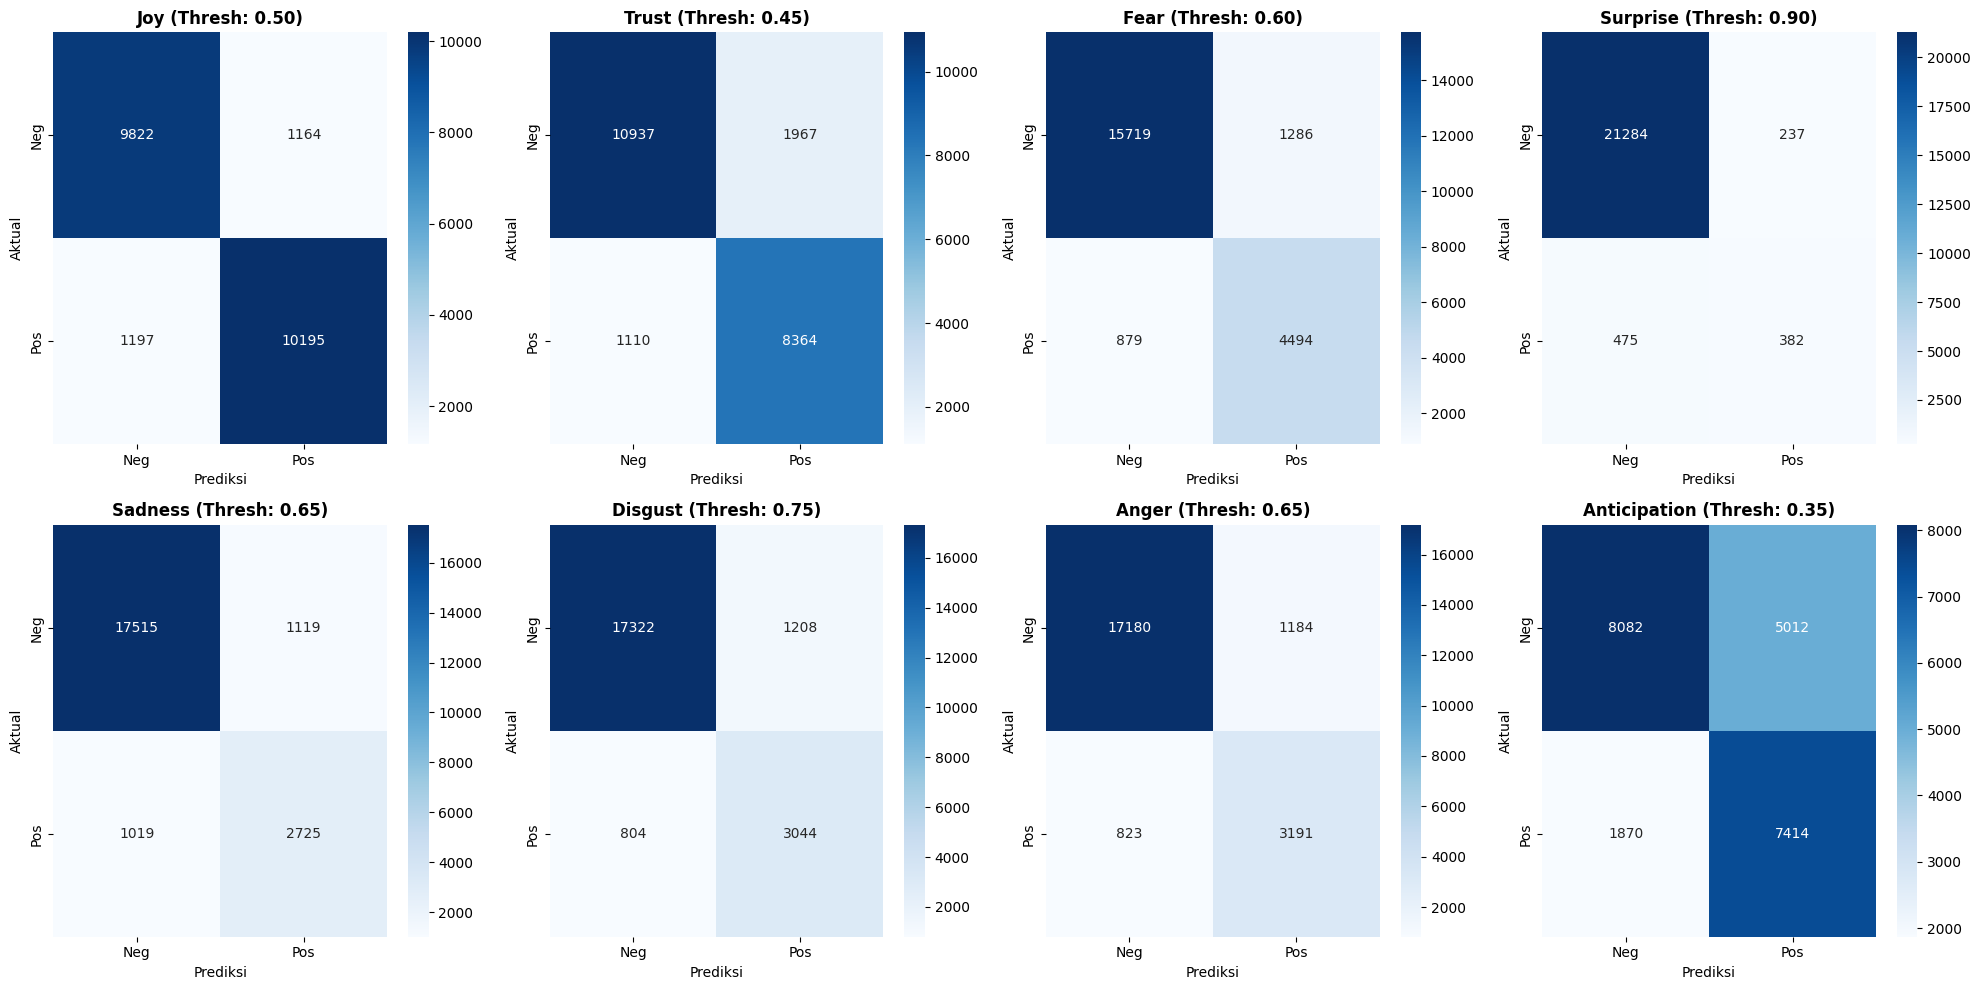


Confusion matrix plot saved to: ./model/confusion_matrices.png
Detailed metrics per class saved to: ./model/detailed_metrics_per_class.csv
Global metrics saved to: ./model/global_metrics.txt
Classification report saved to: ./model/classification_report.txt


In [11]:
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n=== 1. PENCARIAN DYNAMIC THRESHOLD (MENGGUNAKAN VALIDATION SET) ===")

# Ambil prediksi mentah (logits) dari data VALIDASI
val_output = trainer.predict(eval_dataset)
val_logits = val_output.predictions
val_labels = val_output.label_ids

# Ubah logits ke probabilitas (Sigmoid)
val_probs = torch.sigmoid(torch.tensor(val_logits)).numpy()

# Cari threshold terbaik untuk SETIAP label
best_thresholds = np.full(num_labels, 0.5)
search_range = np.arange(0.1, 0.95, 0.05)

print("Mengoptimalkan threshold per label...")
for i in range(num_labels):
    best_f1 = 0
    best_thresh = 0.5
    for thresh in search_range:
        preds = (val_probs[:, i] > thresh).astype(int)
        current_f1 = f1_score(val_labels[:, i], preds, zero_division=0)

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_thresh = thresh

    best_thresholds[i] = best_thresh

# Tampilkan Threshold terpilih
thresh_df = pd.DataFrame({'Label': label_columns, 'Optimized Threshold': best_thresholds})
print(thresh_df)


print("\n=== 2. EVALUASI TEST SET (DENGAN DYNAMIC THRESHOLD) ===")

# Ambil prediksi mentah dari data TEST
test_output = trainer.predict(test_dataset)
test_probs = torch.sigmoid(torch.tensor(test_output.predictions)).numpy()
test_labels_true = test_output.label_ids

# Array untuk menyimpan prediksi final
final_test_preds = np.zeros_like(test_probs, dtype=int)

# Terapkan threshold yang sudah dioptimalkan
for i in range(num_labels):
    final_test_preds[:, i] = (test_probs[:, i] > best_thresholds[i]).astype(int)

# --- HITUNG METRIK ---

# 1. Metrik Global
global_acc = accuracy_score(test_labels_true, final_test_preds)
global_f1_macro = f1_score(test_labels_true, final_test_preds, average='macro')
global_f1_micro = f1_score(test_labels_true, final_test_preds, average='micro')

print(f"\n[Global Metrics]")
print(f"Accuracy (Exact Match): {global_acc:.4f}")
print(f"F1 Macro Average      : {global_f1_macro:.4f}")
print(f"F1 Micro Average      : {global_f1_micro:.4f}")

# 2. Metrik Per Kelas
f1_per_class = f1_score(test_labels_true, final_test_preds, average=None)
prec_per_class = precision_score(test_labels_true, final_test_preds, average=None, zero_division=0)
rec_per_class = recall_score(test_labels_true, final_test_preds, average=None, zero_division=0)

# Buat DataFrame Laporan
df_metrics = pd.DataFrame({
    'Label': label_columns,
    'Threshold': best_thresholds,
    'Precision': prec_per_class,
    'Recall': rec_per_class,
    'F1-Score': f1_per_class
})

print("\n[Detailed Metrics Per Class]")
print(df_metrics.round(4).to_string(index=False))

# 3. Tampilkan Classification Report standar (format teks)
print("\n--- SKLEARN CLASSIFICATION REPORT ---")
print(classification_report(test_labels_true, final_test_preds, target_names=label_columns, zero_division=0))

# --- VISUALISASI CONFUSION MATRIX ---
print("\n=== 3. VISUALISASI CONFUSION MATRIX ===")

# Siapkan grid plot (sesuaikan ukuran figsize jika perlu)
# Jika label ada 8, kita buat 2 baris x 4 kolom
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, label_name in enumerate(label_columns):
    # Hitung CM menggunakan prediksi yang sudah di-threshold
    cm = confusion_matrix(
        y_true=test_labels_true[:, i],
        y_pred=final_test_preds[:, i]
    )

    # Plot Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])

    axes[i].set_title(f"{label_name.title()} (Thresh: {best_thresholds[i]:.2f})", fontweight='bold')
    axes[i].set_xlabel('Prediksi')
    axes[i].set_ylabel('Aktual')

plt.tight_layout()
plt.show()


# save plot to drive
# --- Generate, Save, and Log Confusion Matrix Plot ---
final_model_path = "./model"
os.makedirs(final_model_path, exist_ok=True)
cm_plot_path = os.path.join(final_model_path, "confusion_matrices.png")
fig.savefig(cm_plot_path)
print(f"\nConfusion matrix plot saved to: {cm_plot_path}")

# simpan laporan metrik ke CSV
metrics_csv_path = os.path.join(final_model_path, "detailed_metrics_per_class.csv")
df_metrics.to_csv(metrics_csv_path, index=False)
print(f"Detailed metrics per class saved to: {metrics_csv_path}")

# simpan laporan global metrik ke TXT
global_metrics_txt_path = os.path.join(final_model_path, "global_metrics.txt")
with open(global_metrics_txt_path, 'w') as f:
    f.write(f"Global Metrics:\n")
    f.write(f"Accuracy (Exact Match): {global_acc:.4f}\n")
    f.write(f"F1 Macro Average      : {global_f1_macro:.4f}\n")
    f.write(f"F1 Micro Average      : {global_f1_micro:.4f}\n")
print(f"Global metrics saved to: {global_metrics_txt_path}")

# simpan classification report ke TXT
classification_report_txt_path = os.path.join(final_model_path, "classification_report.txt")
with open(classification_report_txt_path, 'w') as f:
    f.write(classification_report(test_labels_true, final_test_preds, target_names=label_columns, zero_division=0))
print(f"Classification report saved to: {classification_report_txt_path}")

In [12]:
# --- TAMBAHAN: LOGGING MANUAL KE WANDB ---
import wandb

# Cek apakah W&B sedang aktif
if wandb.run is not None:
    print("\nMengirim hasil evaluasi Dynamic Threshold ke W&B...")

    # 1. Log Metrik Global (dengan suffix '_dynamic' agar beda dengan default)
    wandb.log({
        "test/accuracy_dynamic": accuracy_score(test_labels_true, final_test_preds),
        "test/f1_macro_dynamic": f1_score(test_labels_true, final_test_preds, average='macro'),
        "test/f1_micro_dynamic": f1_score(test_labels_true, final_test_preds, average='micro'),
    })

    # 2. Log Metrik Per Label & Threshold yang dipakai
    for i, label in enumerate(label_columns):
        wandb.log({
            f"test_per_class/f1_{label}": f1_score(test_labels_true[:, i], final_test_preds[:, i], zero_division=0),
            f"test_per_class/threshold_{label}": best_thresholds[i]
        })

    # 3. Log Hyperparameter Bobot (w1, w2) - Penting untuk tuning!
    # Mengakses atribut w1/w2 dari model (pastikan model masih ada di memori)
    if hasattr(model, 'w1') and hasattr(model, 'w2'):
        wandb.log({
            "hyperparams/weight_text (w1)": model.w1,
            "hyperparams/weight_emoji (w2)": model.w2
        })

    # 4. Log Gambar Confusion Matrix
    # 'fig' diambil dari plot matplotlib di kode sebelumnya
    wandb.log({"confusion_matrix_dynamic": wandb.Image(fig)})

    print("Log ke W&B berhasil.")
else:
    print("\nW&B run tidak terdeteksi. Hasil tidak di-upload.")

wandb.finish()


Mengirim hasil evaluasi Dynamic Threshold ke W&B...
Log ke W&B berhasil.


# LANGKAH 8: MENYIMPAN MODEL DAN TOKENIZER FINAL
## Menyimpan model yang sudah di-fine-tuning untuk digunakan nanti.

In [14]:
import os
import shutil
from google.colab import drive

# 1. Simpan dulu di Runtime Colab (Local)
print(f"\nMenyimpan model dan tokenizer final ke '{final_model_path}'...")
trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)
print("Model dan tokenizer berhasil disimpan di Runtime Colab.")

# 2. Mount Google Drive
print("\nMounting Google Drive...")
drive.mount('/content/drive')

# 3. Tentukan path tujuan di Google Drive
drive_save_path = "/content/drive/MyDrive/TEA Multi Modal Project/Model_v2/Baseline_noEmoji/run_5"

# 4. Menyalin seluruh folder dari Runtime ke Drive
print(f"\nMenyalin folder dari '{final_model_path}' ke '{drive_save_path}'...")

try:
    # dirs_exist_ok=True memungkinkan penyalinan meskipun folder tujuan sudah ada (akan di-overwrite/merge)
    shutil.copytree(final_model_path, drive_save_path, dirs_exist_ok=True)
    print(f"Sukses! Folder berhasil disalin ke: {drive_save_path}")
except Exception as e:
    print(f"Terjadi kesalahan saat menyalin: {e}")


Menyimpan model dan tokenizer final ke './model'...
Model dan tokenizer berhasil disimpan di Runtime Colab.

Mounting Google Drive...
Mounted at /content/drive

Menyalin folder dari './model' ke '/content/drive/MyDrive/TEA Multi Modal Project/Model_v2/Baseline_noEmoji/run_5'...
Sukses! Folder berhasil disalin ke: /content/drive/MyDrive/TEA Multi Modal Project/Model_v2/Baseline_noEmoji/run_5


eval/accuracy,▁▃▅▇██
eval/f1_macro,▁▃▅▇██
eval/f1_micro,▁▃▅▇██
eval/loss,▃▁▁▅██
eval/precision_micro,▁▃▅▇██
eval/recall_micro,▁▆▇█▄▃
eval/runtime,▁▅▆▆██
eval/samples_per_second,█▄▃▃▁▁
eval/steps_per_second,█▄▃▃▁▁
test/accuracy,█▁
+32,...
